# Deep-Dive House Prices Exploratory Data Analysis (EDA)

This notebook provides an in-depth exploratory analysis of the house prices dataset, focusing on statistical insights, outlier detection, and complex correlations. 

**Note:** This notebook is strictly for EDA. No feature engineering or preprocessing steps are included here.

## 1. Import Libraries and Load Data

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('house_prices.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,N,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,N,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,N,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,N,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,N,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## 2. Statistical Overview

Let's examine the central tendency, dispersion, and shape of the dataset's distribution.

In [17]:
# Detailed summary statistics
summary_stats = df.describe().T
summary_stats['skew'] = df.skew(numeric_only=True)
summary_stats['kurtosis'] = df.kurt(numeric_only=True)
summary_stats

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09,0.243329,-1.260542
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06,4.024069,34.585540
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01,1.974300,49.063653
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00,0.511108,1.279902
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04,1.471555,5.243093
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06,13.060019,285.077820
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00,0.616177,-0.484723
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,3.395750,10.893022
grade,21613.0,7.656873e+00,1.175459e+00,1.000000e+00,7.000000e+00,7.000000e+00,8.000000e+00,1.300000e+01,0.771103,1.190932
sqft_above,21613.0,1.788391e+03,8.280910e+02,2.900000e+02,1.190000e+03,1.560000e+03,2.210000e+03,9.410000e+03,1.446664,3.402304


## 3. Data Integrity Check

Checking for missing values and unique counts to understand data quality.

In [18]:
integrity_check = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    '% Missing': (df.isnull().sum() / len(df)) * 100,
    'Unique Values': df.nunique(),
    'Data Type': df.dtypes
})
integrity_check

,Missing Values,% Missing,Unique Values,Data Type
id,0,0.0,21436,int64
date,0,0.0,372,object
price,0,0.0,4028,float64
bedrooms,0,0.0,13,int64
bathrooms,0,0.0,30,float64
sqft_living,0,0.0,1038,int64
sqft_lot,0,0.0,9782,int64
floors,0,0.0,6,float64
waterfront,0,0.0,2,object
view,0,0.0,5,int64


## 4. Target Variable Analysis: Price

Analyzing the distribution of `price` and its normality.

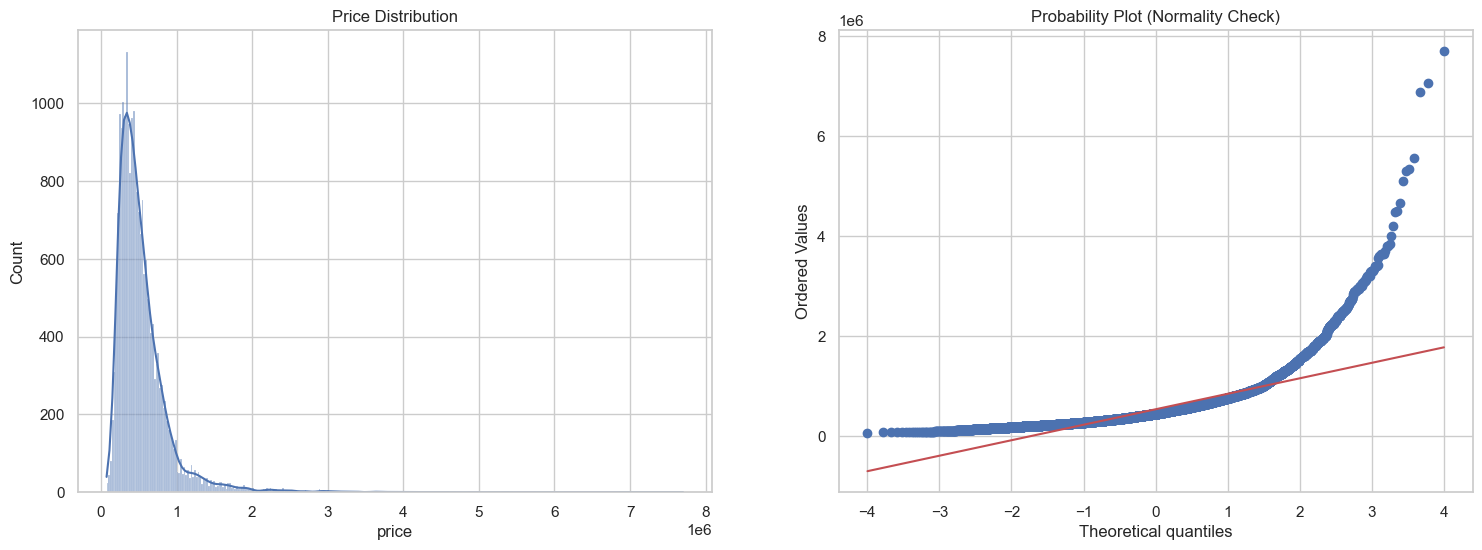

Price Skewness: 4.02
Price Kurtosis: 34.59


In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Histogram with KDE
sns.histplot(df['price'], kde=True, ax=ax1)
ax1.set_title('Price Distribution')

# Probability Plot (Q-Q Plot)
stats.probplot(df['price'], plot=ax2)
ax2.set_title('Probability Plot (Normality Check)')

plt.show()

print(f"Price Skewness: {df['price'].skew():.2f}")
print(f"Price Kurtosis: {df['price'].kurt():.2f}")

## 5. Outlier Analysis

Identifying outliers using the Interquartile Range (IQR) method and boxplots for key numerical features.

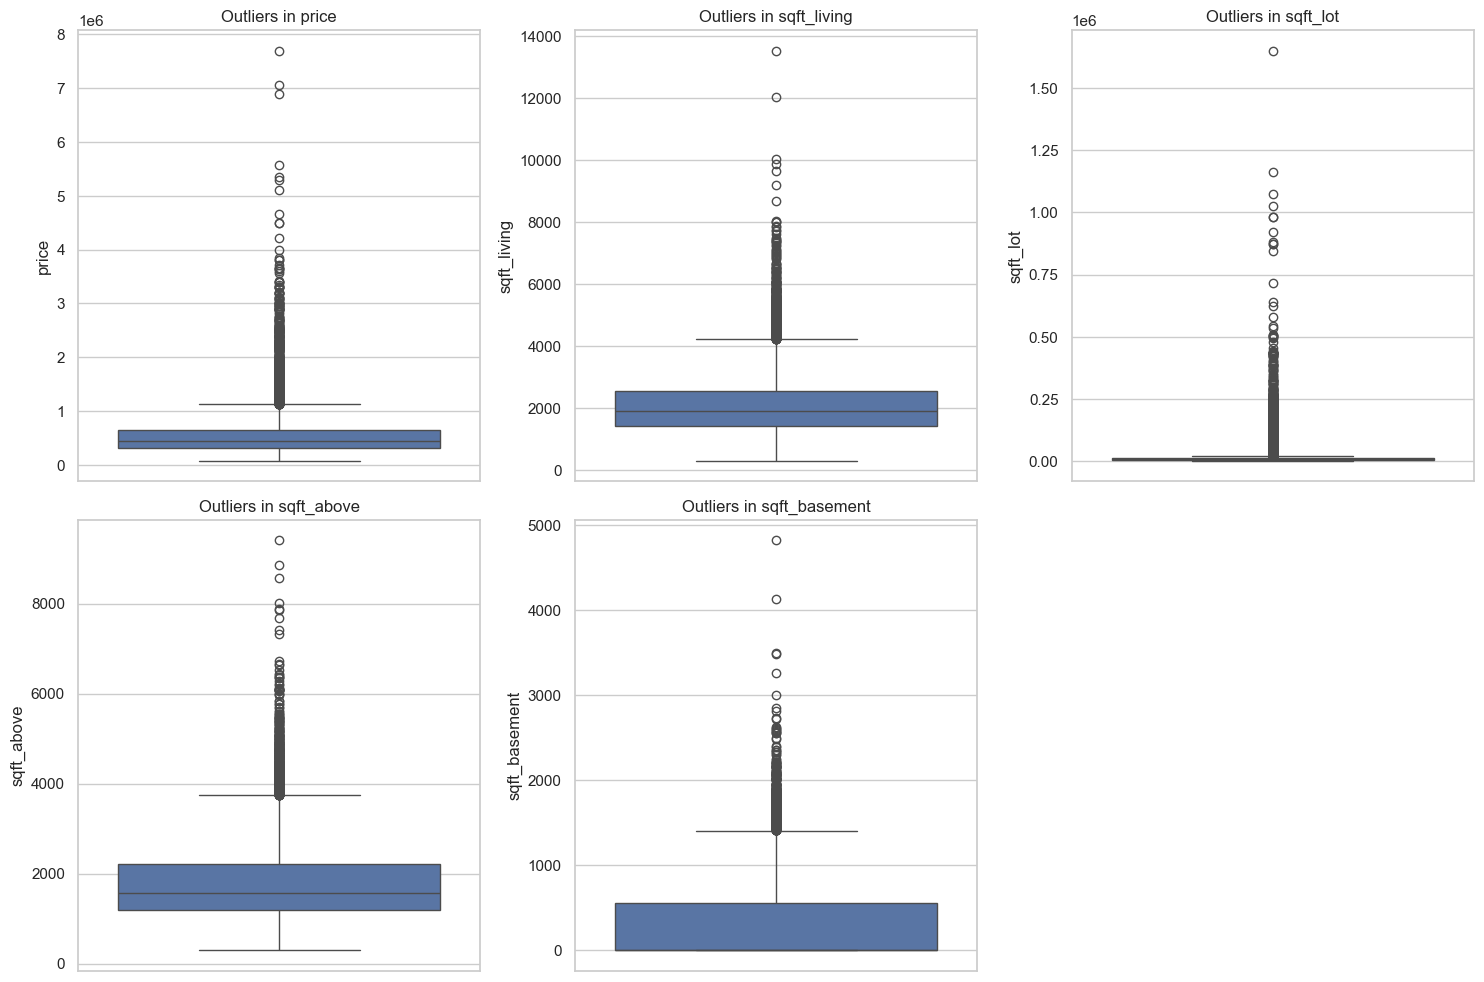

price: 1146 outliers detected (Bounds: -162625.00 to 1129575.00)
sqft_living: 572 outliers detected (Bounds: -257.50 to 4234.50)
sqft_lot: 2425 outliers detected (Bounds: -3432.00 to 19160.00)
sqft_above: 611 outliers detected (Bounds: -340.00 to 3740.00)
sqft_basement: 496 outliers detected (Bounds: -840.00 to 1400.00)


In [20]:
numerical_cols = ['price', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement']

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Visualize outliers with boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

# Print outlier counts
for col in numerical_cols:
    outliers, lb, ub = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers detected (Bounds: {lb:.2f} to {ub:.2f})")

## 6. Correlation Matrix

Exploring the linear relationships between all numerical variables.

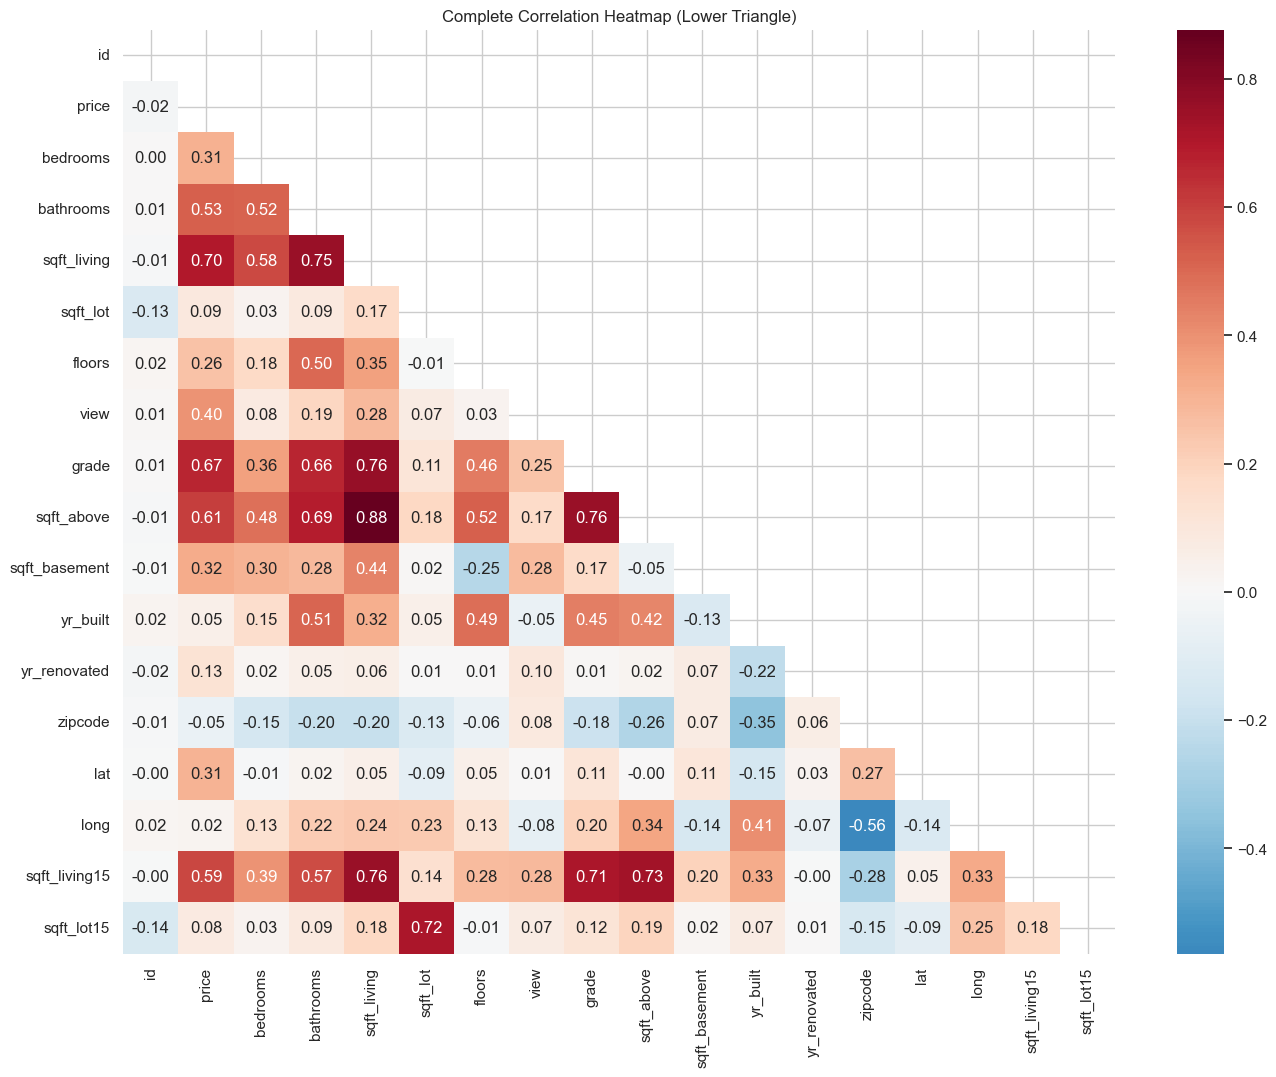

In [21]:
# Correlation matrix for all numerical columns
corr_matrix = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', fmt='.2f', center=0)
plt.title('Complete Correlation Heatmap (Lower Triangle)')
plt.show()

### Top Features Correlated with Price

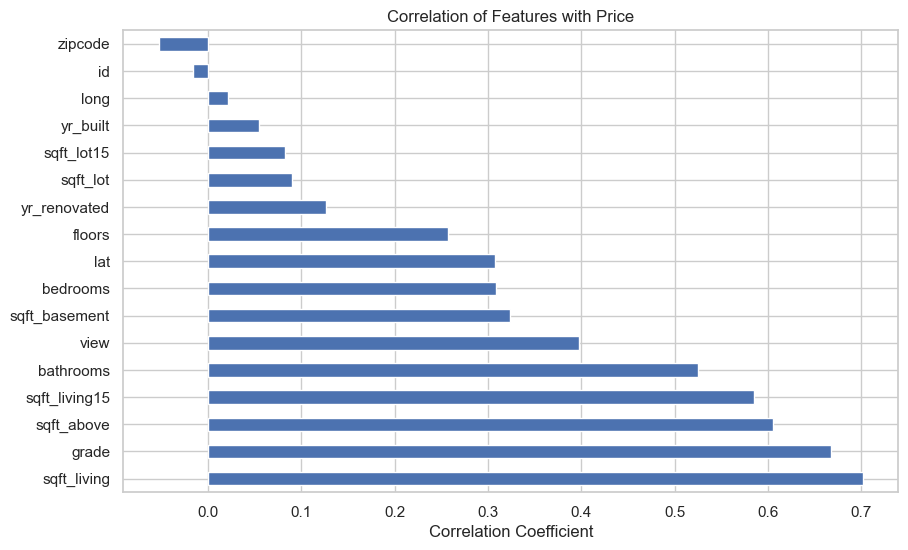

In [22]:
price_correlations = corr_matrix['price'].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
price_correlations.drop('price').plot(kind='barh')
plt.title('Correlation of Features with Price')
plt.xlabel('Correlation Coefficient')
plt.show()

## 7. Multicollinearity Insights

Identifying features that are highly correlated with each other (potential multicollinearity).

In [23]:
# Find pairs with correlation > 0.8
high_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[(high_corr > 0.8) & (high_corr < 1.0)]
print("Highly Correlated Pairs (>0.8):")
print(high_corr.drop_duplicates())

Highly Correlated Pairs (>0.8):
sqft_above  sqft_living    0.876597
dtype: float64


## 8. Discrete Variable Analysis

Analyzing the impact of discrete features like `view`, `waterfront`, and `condition` on price.

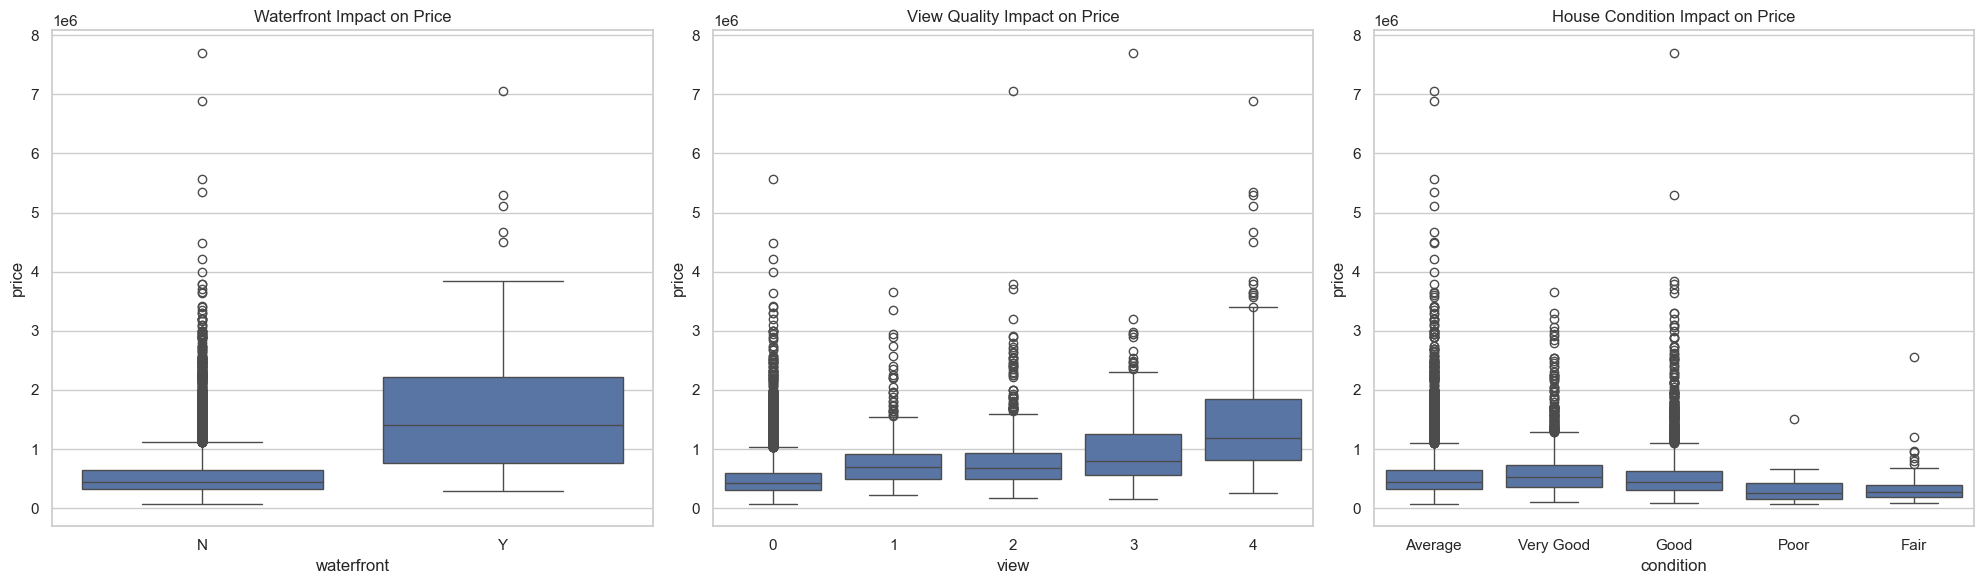

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Waterfront vs Price
sns.boxplot(x='waterfront', y='price', data=df, ax=axes[0])
axes[0].set_title('Waterfront Impact on Price')

# View vs Price
sns.boxplot(x='view', y='price', data=df, ax=axes[1])
axes[1].set_title('View Quality Impact on Price')

# Condition vs Price
sns.boxplot(x='condition', y='price', data=df, ax=axes[2])
axes[2].set_title('House Condition Impact on Price')

plt.tight_layout()
plt.show()

## 9. Key EDA Insights

1. **Price Distribution**: The target variable is highly right-skewed, suggesting a need for transformation (e.g., log-transform) in the preprocessing phase.
2. **Outliers**: Significant outliers exist in `price`, `sqft_lot`, and `sqft_living`. These represent luxury properties or large estates.
3. **Strongest Predictors**: `sqft_living`, `grade`, `sqft_above`, and `sqft_living15` show the strongest positive correlations with price.
4. **Multicollinearity**: High correlation between `sqft_living` and `sqft_above` (0.88) suggests they carry redundant information.
5. **Categorical Impact**: Waterfront properties and houses with higher 'view' ratings command significantly higher median prices.